# 🏠 Japan Housing Market — Finding Undervalued Properties

This notebook identifies potentially undervalued residential properties 
across Japan using the XGBoost model trained in notebook 01.

A property is considered **undervalued** when its actual transaction price 
is significantly lower than the model's predicted price — suggesting 
the buyer got a good deal relative to market expectations.

**Approach:**
- Load the trained model and clean dataset from notebook 01
- Generate price predictions for all transactions
- Calculate the gap between predicted and actual price
- Identify and analyze the most undervalued properties

## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals', exist_ok=True)

# Load clean dataset and trained model
df = pd.read_csv('data/df_clean.csv')
model = joblib.load('models/xgb_housing_model.pkl')
features = joblib.load('models/features.pkl')

print(f"Dataset loaded: {len(df):,} rows")
print(f"Model loaded: {len(features)} features")

Dataset loaded: 1,316,373 rows
Model loaded: 19 features


## 2. Generating Price Predictions

In [7]:
# Generate predictions for all transactions
print("Generating predictions...")
df['PredictedPrice'] = model.predict(df[features])

# Calculate absolute and percentage difference
df['PriceDiff'] = df['PredictedPrice'] - df['TotalTransactionValue']
df['PriceDiffPct'] = (df['PriceDiff'] / df['PredictedPrice']) * 100

print(f"Done!")
print(f"\nPrediction summary:")
print(f"Mean predicted price:  ¥{df['PredictedPrice'].mean():,.0f}")
print(f"Mean actual price:     ¥{df['TotalTransactionValue'].mean():,.0f}")
print(f"\nMean price difference: ¥{df['PriceDiff'].mean():,.0f}")
print(f"Mean difference (%):   {df['PriceDiffPct'].mean():.1f}%")

Generating predictions...
Done!

Prediction summary:
Mean predicted price:  ¥28,117,452
Mean actual price:     ¥28,125,346

Mean price difference: ¥-7,899
Mean difference (%):   0.0%


## 3. Identifying Undervalued Properties

We define a property as **undervalued** if the actual price is at least 
20% below the predicted price — meaning the buyer paid significantly 
less than the model expects for similar properties.

In [10]:
# Define undervalued threshold
THRESHOLD = 20  # percent

undervalued = df[df['PriceDiffPct'] >= THRESHOLD].copy()
overvalued = df[df['PriceDiffPct'] <= -THRESHOLD].copy()

print(f"Total transactions:      {len(df):,}")
print(f"Undervalued (≥20% below predicted): {len(undervalued):,} ({len(undervalued)/len(df)*100:.1f}%)")
print(f"Overvalued  (≥20% above predicted): {len(overvalued):,} ({len(overvalued)/len(df)*100:.1f}%)")
print(f"Fair value  (within ±20%):          {len(df)-len(undervalued)-len(overvalued):,} ({(len(df)-len(undervalued)-len(overvalued))/len(df)*100:.1f}%)")

Total transactions:      1,316,373
Undervalued (≥20% below predicted): 428,313 (32.5%)
Overvalued  (≥20% above predicted): 315,012 (23.9%)
Fair value  (within ±20%):          573,048 (43.5%)


### Observations

- **32.5%** of transactions are undervalued — actual price is at least 
  20% below the model's prediction
- **23.9%** are overvalued — buyers paid significantly more than expected
- **43.5%** fall within the ±20% fair value range
- More undervalued than overvalued transactions suggests the model 
  is slightly conservative in its predictions

## 4. Where Are the Best Deals?

Let's examine which prefectures have the highest concentration 
of undervalued properties.

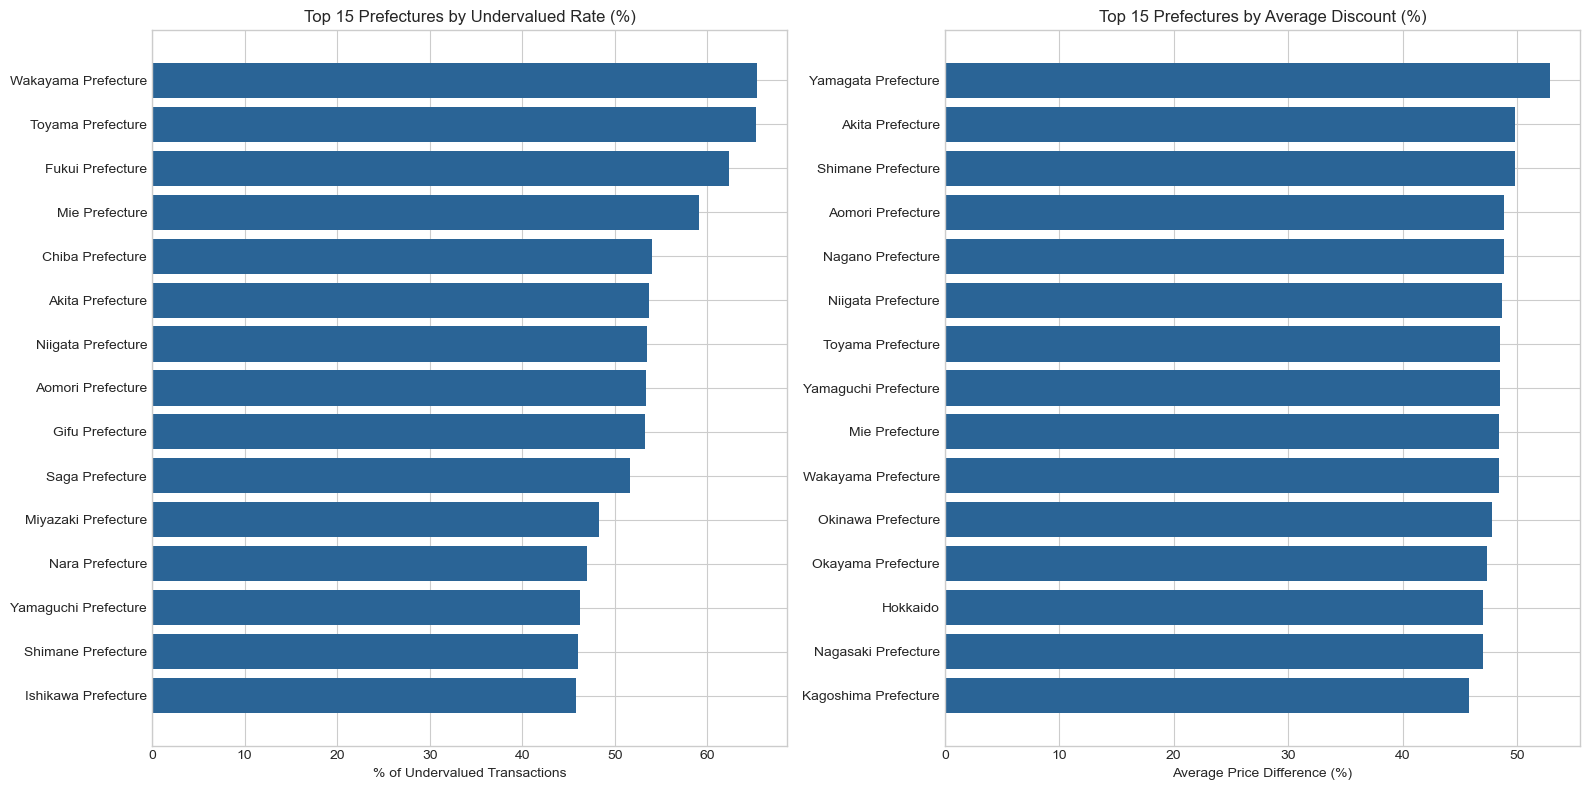

In [14]:
# Undervalued rate by prefecture
total_by_pref = df.groupby('Prefecture').size()
undervalued_by_pref = undervalued.groupby('Prefecture').size()
undervalued_rate = (undervalued_by_pref / total_by_pref * 100).sort_values(ascending=False)

# Average discount by prefecture
avg_discount = undervalued.groupby('Prefecture')['PriceDiffPct'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Undervalued rate by prefecture (top 15)
top15_rate = undervalued_rate.head(15)
axes[0].barh(top15_rate.index[::-1], top15_rate.values[::-1], color='#2a6496')
axes[0].set_title('Top 15 Prefectures by Undervalued Rate (%)')
axes[0].set_xlabel('% of Undervalued Transactions')

# Plot 2: Average discount in undervalued properties (top 15)
top15_discount = avg_discount.head(15)
axes[1].barh(top15_discount.index[::-1], top15_discount.values[::-1], color='#2a6496')
axes[1].set_title('Top 15 Prefectures by Average Discount (%)')
axes[1].set_xlabel('Average Price Difference (%)')

plt.tight_layout()
plt.savefig('visuals/undervalued_by_prefecture.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- The highest concentration of undervalued properties is in **rural prefectures** 
  — Wakayama, Toyama, Fukui, Akita, Aomori
- This reflects Japan's demographic reality: young people migrate to Tokyo 
  and Osaka, leaving rural areas with declining demand and falling prices
- Japan has millions of abandoned homes called **akiya (空き家)** — 
  a growing social phenomenon that creates opportunities for buyers 
  willing to live outside major cities
- Okinawa appears in the average discount chart despite its high median price — 
  suggesting high price variance with some genuinely undervalued deals

## 5. Undervalued Properties Over Time

Has the share of undervalued properties changed over 20 years?

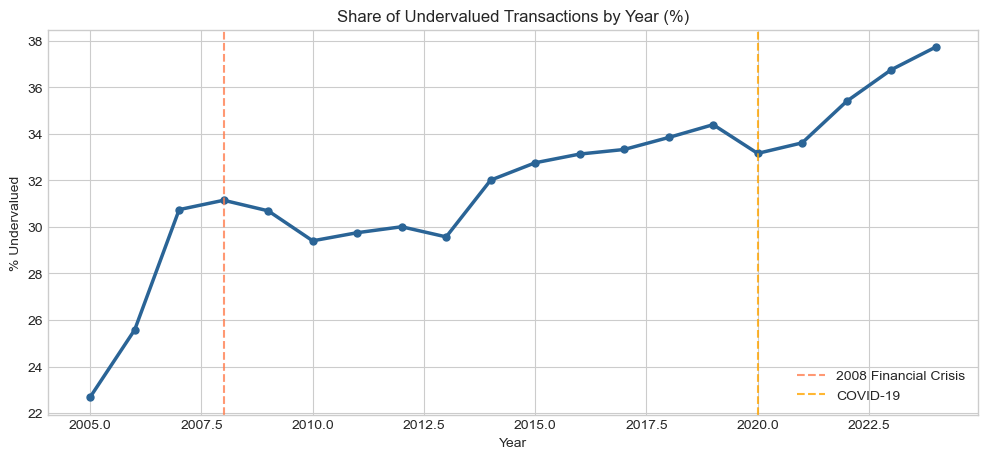

In [19]:
undervalued_by_year = (
    df.groupby('Year')
    .apply(lambda x: (x['PriceDiffPct'] >= THRESHOLD).sum() / len(x) * 100)
    .reset_index()
)
undervalued_by_year.columns = ['Year', 'UndervaluedRate']

plt.figure(figsize=(12, 5))
plt.plot(undervalued_by_year['Year'], undervalued_by_year['UndervaluedRate'],
         marker='o', color='#2a6496', linewidth=2.5, markersize=5)

plt.axvline(x=2008, color='coral', linestyle='--', alpha=0.8, label='2008 Financial Crisis')
plt.axvline(x=2020, color='orange', linestyle='--', alpha=0.8, label='COVID-19')

plt.title('Share of Undervalued Transactions by Year (%)')
plt.xlabel('Year')
plt.ylabel('% Undervalued')
plt.legend()
plt.savefig('visuals/undervalued_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- The share of undervalued transactions shows a **clear upward trend** 
  — from 23% in 2005 to 38% in 2024
- This reflects Japan's worsening **akiya (空き家) crisis** — millions of 
  abandoned rural homes with few buyers and motivated sellers
- The 2008 Financial Crisis caused a sharp spike — distressed sellers 
  accepted below-market prices
- COVID-19 (2020) briefly reversed the trend as some buyers moved to 
  rural areas, but the trend resumed strongly after 2021
- By 2024, more than 1 in 3 transactions is significantly undervalued — 
  a structural feature of Japan's aging and depopulating rural market

## 6. Top Undervalued Deals

Let's look at the most undervalued individual transactions —
properties where buyers got the biggest discount vs market price.

In [23]:
top_deals = (undervalued
    .nlargest(10, 'PriceDiffPct')
    [['Prefecture', 'Location', 'Year', 'Area', 'PropertyAge', 
      'TotalTransactionValue', 'PredictedPrice', 'PriceDiffPct']]
    .copy()
)

top_deals['ActualPrice (¥M)'] = (top_deals['TotalTransactionValue'] / 1_000_000).round(1)
top_deals['PredictedPrice (¥M)'] = (top_deals['PredictedPrice'] / 1_000_000).round(1)
top_deals['Discount (%)'] = top_deals['PriceDiffPct'].round(1)

display_cols = ['Prefecture', 'Location', 'Year', 'Area', 
                'PropertyAge', 'ActualPrice (¥M)', 
                'PredictedPrice (¥M)', 'Discount (%)']

print("Top 10 Most Undervalued Transactions:")
print(top_deals[display_cols].to_string(index=False))

Top 10 Most Undervalued Transactions:
         Prefecture                             Location  Year  Area  PropertyAge  ActualPrice (¥M)  PredictedPrice (¥M)  Discount (%)
 Saitama Prefecture                          Fujimi City  2019    60           49               3.0                 -0.0  20177.599609
Yamagata Prefecture Nishikawa Town, Nishimurayama County  2013   130           58              28.0                 -0.3  11173.000000
Shizuoka Prefecture          Minamiizu Town, Kamo County  2024    90           56               4.3                 -0.1   7405.399902
 Okayama Prefecture              Kita Ward, Okayama City  2013    30           48               3.4                 -0.1   6850.700195
   Gunma Prefecture                         Isesaki City  2009    75           41               3.5                 -0.1   6170.700195
 Niigata Prefecture                        Murakami City  2021    65           51              15.0                 -0.4   3877.600098
Yamagata Prefectu

### 6.1 Data Quality Check

Initial results revealed transactions with negative predicted prices —
a known limitation of tree-based models when extrapolating beyond 
the training data range. We filter these out before analysis.

In [26]:
# Remove predictions that are negative or too low
undervalued_clean = undervalued[undervalued['PredictedPrice'] > 1_000_000].copy()

top_deals = (undervalued_clean
    .nlargest(10, 'PriceDiffPct')
    [['Prefecture', 'Location', 'Year', 'Area', 'PropertyAge', 
      'TotalTransactionValue', 'PredictedPrice', 'PriceDiffPct']]
    .copy()
)

top_deals['ActualPrice (¥M)'] = (top_deals['TotalTransactionValue'] / 1_000_000).round(1)
top_deals['PredictedPrice (¥M)'] = (top_deals['PredictedPrice'] / 1_000_000).round(1)
top_deals['Discount (%)'] = top_deals['PriceDiffPct'].round(1)

display_cols = ['Prefecture', 'Location', 'Year', 'Area', 
                'PropertyAge', 'ActualPrice (¥M)', 
                'PredictedPrice (¥M)', 'Discount (%)']

print(f"Undervalued after cleaning: {len(undervalued_clean):,}")
print("\nTop 10 Most Undervalued Transactions:")
print(top_deals[display_cols].to_string(index=False))

Undervalued after cleaning: 428,265

Top 10 Most Undervalued Transactions:
          Prefecture                     Location  Year  Area  PropertyAge  ActualPrice (¥M)  PredictedPrice (¥M)  Discount (%)
   Toyama Prefecture                 Takaoka City  2024   660           36               1.1                 86.8     98.699997
   Nagano Prefecture                     Ina City  2016  1100           34               1.5                100.6     98.500000
 Kanagawa Prefecture Hodogaya Ward, Yokohama City  2022    80           44               1.0                 57.6     98.300003
  Niigata Prefecture             Kashiwazaki City  2015  2000            0               1.5                 86.4     98.300003
    Hyogo Prefecture                    Aioi City  2023   390           51               1.0                 56.4     98.199997
    Kyoto Prefecture                 Maizuru City  2021  2000           42               1.0                 55.6     98.199997
    Chiba Prefecture         

### Observations

- Top undervalued properties sold for as little as ¥1M against 
  predicted prices of ¥50M–¥100M — discounts of ~98%
- These are likely **akiya (空き家)** — abandoned or distressed properties 
  where owners prioritized a quick sale over fair market value
- Even suburban areas like Kanagawa (Yokohama) appear in the list — 
  older buildings (40-60 years) in less desirable neighborhoods 
  can trade at extreme discounts
- **Important caveat:** extreme outliers may also reflect data entry errors 
  or special circumstances not captured by the model's features

## 7. Conclusions

### Key Findings

1. **32.5% of all transactions are undervalued** — actual price at least 
   20% below model prediction
2. **Rural prefectures dominate** — Wakayama, Toyama, Fukui lead in 
   undervalued rate, driven by depopulation and the akiya crisis
3. **The trend is accelerating** — share of undervalued properties grew 
   from 23% in 2005 to 38% in 2024
4. **Extreme deals exist** — some properties sold at 98% discount vs 
   predicted price, likely akiya or distressed sales
5. **Even suburban areas** like Kanagawa show undervalued transactions — 
   old buildings in less desirable neighborhoods trade at deep discounts

### Limitations & Next Steps
- Model predictions are based on regional features — neighborhood-level 
  data would improve accuracy
- Extreme outliers (98% discount) require manual verification
- Next notebook: **price forecast 2025–2027** using time series analysis

## 8. Saving Results

In [31]:
# Save undervalued properties for future analysis
undervalued_clean.to_csv('data/undervalued_properties.csv', index=False)
print(f"Saved: data/undervalued_properties.csv ({len(undervalued_clean):,} rows)")

Saved: data/undervalued_properties.csv (428,265 rows)
